<a href="https://colab.research.google.com/github/dashatenoff/OOP/blob/master/hack_exo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#EXO

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import numpy as np
import os

base_path = "/content/drive/MyDrive/Colab Notebooks/hack/exo"

folders = ["mexo1", "mexo2a", "mexo2b", "mexo3"]

for folder in folders:

    folder_path = os.path.join(base_path, folder)

    files = os.listdir(folder_path)

    print(folder, ":", len(files), "files")

mexo1 : 12 files
mexo2a : 24 files
mexo2b : 24 files
mexo3 : 24 files


In [3]:
import pandas as pd
import os

base_path = "/content/drive/MyDrive/Colab Notebooks/hack/exo"

folders = ["mexo1", "mexo2a", "mexo2b", "mexo3"]

data = []
labels = []
groups = []

for folder in folders:

    folder_path = os.path.join(base_path, folder)

    for file in os.listdir(folder_path):
        print("\nReading:", folder, file)

        file_path = os.path.join(folder_path, file)

        df = pd.read_csv(
            file_path,
            sep=r"\s+",
            header=None,
            skiprows=1,
            names=["X","Y","Wave","Intensity"]
        )

        spectra_count = df.groupby(["X","Y"]).ngroups
        print("Spectra in file:", spectra_count)

        # извлекаем спектры
        for (x, y), group in df.groupby(["X","Y"]):

            spectrum = group["Intensity"].values

            data.append(spectrum)
            labels.append("exo")
            groups.append(folder)

print("Total spectra:", len(data))


Reading: mexo1 cortex_exo_1group_633nm_center1500_obj100_power100_1s_5acc_map35x15_step2_place4_1.txt
Spectra in file: 525

Reading: mexo1 cortex_exo_1group_633nm_center2900_obj100_power100_1s_5acc_map35x15_step2_place4_1.txt
Spectra in file: 525

Reading: mexo1 cortex_exo_1group_633nm_center1500_obj100_power100_1s_5acc_map35x15_step2_place4_2.txt
Spectra in file: 525

Reading: mexo1 cortex_exo_1group_633nm_center1500_obj100_power100_1s_5acc_map35x15_step2_place5_1.txt
Spectra in file: 525

Reading: mexo1 cortex_exo_1group_633nm_center1500_obj100_power100_1s_5acc_map35x15_step2_place5_2.txt
Spectra in file: 525

Reading: mexo1 cortex_exo_1group_633nm_center2900_obj100_power100_1s_5acc_map35x15_step2_place4_2.txt
Spectra in file: 525

Reading: mexo1 cortex_exo_1group_633nm_center2900_obj100_power100_1s_5acc_map35x15_step2_place5_1.txt
Spectra in file: 525

Reading: mexo1 cortex_exo_1group_633nm_center2900_obj100_power100_1s_5acc_map35x15_step2_place5_2.txt
Spectra in file: 525

Reading

In [ ]:
print("Total spectra:", len(data))

Total spectra: 44100


In [ ]:
X = pd.DataFrame(data)
y = pd.Series(labels)

dataset = X.copy()
dataset["label"] = y

In [ ]:
df.shape

(532875, 4)

In [ ]:
df.head()

,X,Y,Wave,Intensity
0,-16346.85859,-21642.364167,2002.354492,15439.225586
1,-16346.85859,-21642.364167,2001.394531,15447.069336
2,-16346.85859,-21642.364167,2000.434570,15386.600586
3,-16346.85859,-21642.364167,1999.474609,15067.408203
4,-16346.85859,-21642.364167,1998.513672,15652.470703


In [ ]:
df.groupby(["X","Y"]).size()

X             Y            
-16346.85859  -21642.364167    1015
              -21640.364167    1015
              -21638.364167    1015
              -21636.364167    1015
              -21634.364167    1015
                               ... 
-16278.85859  -21622.364167    1015
              -21620.364167    1015
              -21618.364167    1015
              -21616.364167    1015
              -21614.364167    1015
Length: 525, dtype: int64

In [ ]:
df.groupby(["X","Y"]).size().unique()

array([1015])

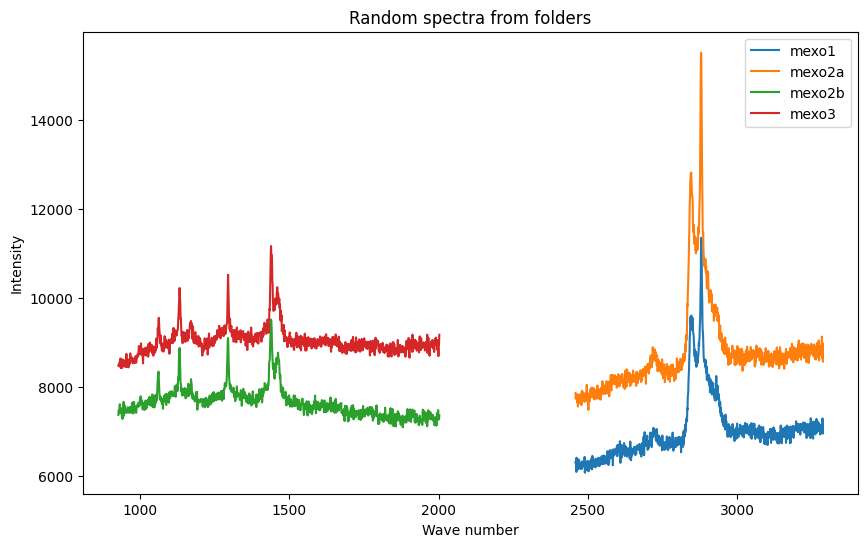

In [ ]:
import random
import matplotlib.pyplot as plt
import pandas as pd
import os

base_path = "/content/drive/MyDrive/Colab Notebooks/hack/exo"

folders = ["mexo1","mexo2a","mexo2b","mexo3"]

plt.figure(figsize=(10,6))

for folder in folders:

    folder_path = os.path.join(base_path, folder)

    file = random.choice(os.listdir(folder_path))

    file_path = os.path.join(folder_path, file)

    df = pd.read_csv(
        file_path,
        sep=r"\s+",
        header=None,
        skiprows=1,
        names=["X","Y","Wave","Intensity"]
    )

    # берём один спектр
    group = list(df.groupby(["X","Y"]))[0][1]

    plt.plot(group["Wave"], group["Intensity"], label=folder)

plt.legend()
plt.title("Random spectra from folders")
plt.xlabel("Wave number")
plt.ylabel("Intensity")

plt.show()

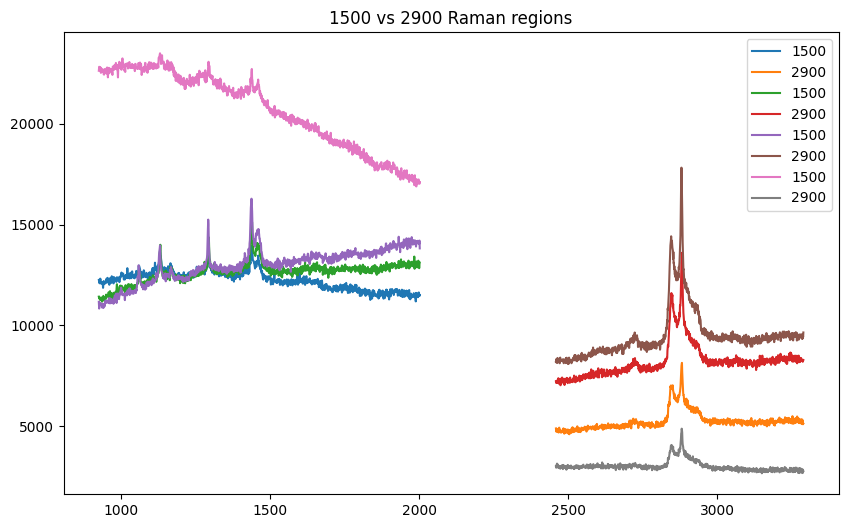

In [ ]:
plt.figure(figsize=(10,6))

for folder in folders:

    folder_path = os.path.join(base_path, folder)

    for file in os.listdir(folder_path):

        if "1500" in file:

            file_path = os.path.join(folder_path, file)

            df = pd.read_csv(
                file_path,
                sep=r"\s+",
                header=None,
                skiprows=1,
                names=["X","Y","Wave","Intensity"]
            )

            group = list(df.groupby(["X","Y"]))[0][1]

            plt.plot(group["Wave"], group["Intensity"], label="1500")

            break

    for file in os.listdir(folder_path):

        if "2900" in file:

            file_path = os.path.join(folder_path, file)

            df = pd.read_csv(
                file_path,
                sep=r"\s+",
                header=None,
                skiprows=1,
                names=["X","Y","Wave","Intensity"]
            )

            group = list(df.groupby(["X","Y"]))[0][1]

            plt.plot(group["Wave"], group["Intensity"], label="2900")

            break

plt.legend()
plt.title("1500 vs 2900 Raman regions")

plt.show()

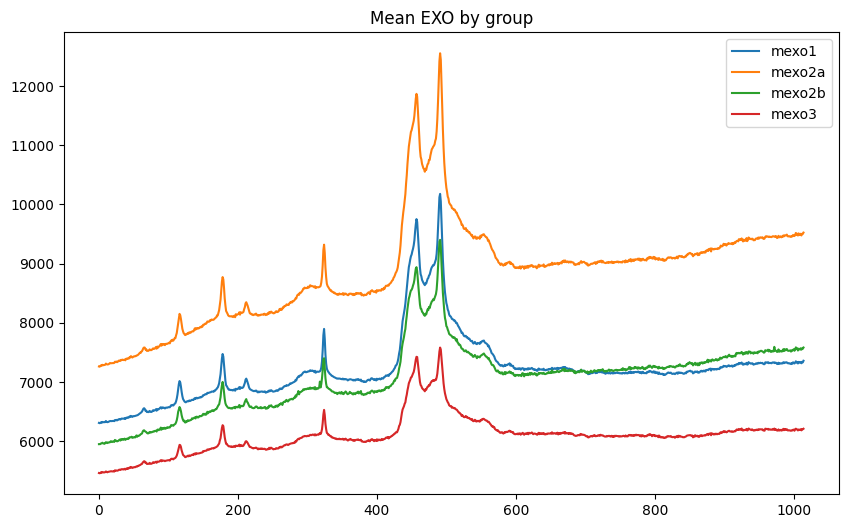

In [ ]:
import numpy as np

plt.figure(figsize=(10,6))

for folder in folders:

    folder_path = os.path.join(base_path, folder)

    spectra = []

    for file in os.listdir(folder_path):

        file_path = os.path.join(folder_path, file)

        df = pd.read_csv(
            file_path,
            sep=r"\s+",
            header=None,
            skiprows=1,
            names=["X","Y","Wave","Intensity"]
        )

        mean_spec = df.groupby("Wave")["Intensity"].mean().values

        spectra.append(mean_spec)

    spectra = np.array(spectra)

    plt.plot(np.mean(spectra, axis=0), label=folder)

plt.legend()

plt.title("Mean EXO by group")

plt.show()

In [ ]:
import numpy as np

print("Components for 90% variance:", np.argmax(cum_var >= 0.90) + 1)
print("Components for 95% variance:", np.argmax(cum_var >= 0.95) + 1)
print("Components for 99% variance:", np.argmax(cum_var >= 0.99) + 1)

##PCA



In [5]:
import numpy as np
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = np.array(data)

y = np.array(labels)
groups = np.array(groups)


print("Shape of X:", X.shape)
print("Number of labels:", len(y))
print(len(groups))
# X_norm = X / X.max(axis=1, keepdims=True)
# X_scaled = scaler.fit_transform(X_norm)

Shape of X: (44100, 1015)
Number of labels: 44100
44100


In [ ]:
print("Min:", X_scaled.min())
print("Max:", X_scaled.max())

Min: -13.009026913023966
Max: 3.5204660120917546


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)
cum_var = np.cumsum(pca.explained_variance_ratio_)

[0.9224038  0.05417095]


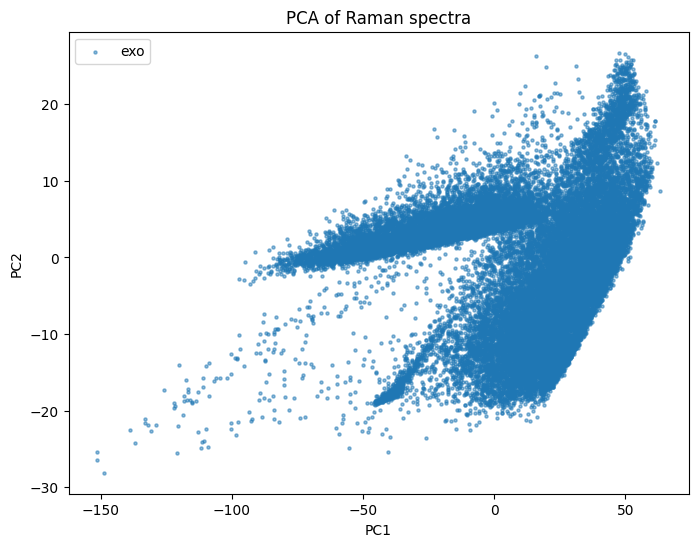

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for label in np.unique(y):

    idx = y == label

    plt.scatter(
        X_pca[idx,0],
        X_pca[idx,1],
        s=5,
        alpha=0.5,
        label=label
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Raman spectra")
plt.legend()

plt.show()

In [ ]:
print("PC1:", pca.explained_variance_ratio_[0])
print("PC2:", pca.explained_variance_ratio_[1])

PC1: 0.9224038028285327
PC2: 0.0541709527691169


##Save

In [ ]:

np.save("/content/drive/MyDrive/Colab Notebooks/hack/X_exo_raw.npy", X)
np.save("/content/drive/MyDrive/Colab Notebooks/hack/X_exo_norm.npy", X_norm)
np.save("/content/drive/MyDrive/Colab Notebooks/hack/X_exo_scaled.npy", X_scaled)

np.save("/content/drive/MyDrive/Colab Notebooks/hack/y_exo.npy", y)

In [6]:
np.save("/content/drive/MyDrive/Colab Notebooks/hack/groups_exo.npy", groups)

In [ ]:
X_test = np.load("/content/drive/MyDrive/Colab Notebooks/hack/X_exo_scaled.npy")

print(X_test.shape)

(44100, 1015)


#ENDO


In [10]:
import pandas as pd
import os

base_path = "/content/drive/MyDrive/Colab Notebooks/hack/endo"

folders = ["mend1", "mend2a", "mend2b", "mend3"]

data_endo = []
labels_endo = []
groups_endo = []
for folder in folders:

    folder_path = os.path.join(base_path, folder)

    for file in os.listdir(folder_path):
        if "Average" in file:
          continue

        print("\nReading:", folder, file)

        file_path = os.path.join(folder_path, file)

        df = pd.read_csv(
            file_path,
            sep=r"\s+",
            header=None,
            skiprows=1,
            names=["X","Y","Wave","Intensity"]
        )

        spectra_count = df.groupby(["X","Y"]).ngroups
        print("Spectra in file:", spectra_count)

        for (x, y), group in df.groupby(["X","Y"]):

            spectrum = group["Intensity"].values

            data_endo.append(spectrum)
            labels_endo.append("endo")
            groups_endo.append(folder)

print("Total ENDO spectra:", len(data_endo))


Reading: mend1 cortex_endo_1group_633nm_center2900_obj100_power100_1s_5acc_map35x15_step2_place1_1.txt
Spectra in file: 525

Reading: mend1 cortex_endo_1group_633nm_center2900_obj100_power100_1s_5acc_map35x15_step2_place1_2.txt
Spectra in file: 525

Reading: mend1 cortex_endo_1group_633nm_center2900_obj100_power100_1s_5acc_map35x15_step2_place2.txt
Spectra in file: 525

Reading: mend1 cortex_endo_1group_633nm_center1500_obj100_power100_1s_5acc_map35x15_step2_place2_2.txt
Spectra in file: 525

Reading: mend1 cortex_endo_1group_633nm_center1500_obj100_power100_1s_5acc_map35x15_step2_place3_1.txt
Spectra in file: 525

Reading: mend1 cortex_endo_1group_633nm_center1500_obj100_power100_1s_5acc_map35x15_step2_place3_2.txt
Spectra in file: 525

Reading: mend1 cortex_endo_1group_633nm_center2900_obj100_power100_1s_5acc_map35x15_step2_place2_1.txt
Spectra in file: 525

Reading: mend1 cortex_endo_1group_633nm_center2900_obj100_power100_1s_5acc_map35x15_step2_place3_1.txt
Spectra in file: 525

R

In [ ]:
df.shape

(532875, 4)

In [ ]:
df.head()

,X,Y,Wave,Intensity
0,1722.02246,-26045.644167,3288.140625,5191.286621
1,1722.02246,-26045.644167,3287.397461,5295.990723
2,1722.02246,-26045.644167,3286.654297,5173.441895
3,1722.02246,-26045.644167,3285.910156,4986.789063
4,1722.02246,-26045.644167,3285.166992,5131.020996


In [ ]:
df.groupby(["X","Y"]).size()

X           Y            
1722.02246  -26045.644167    1015
            -26043.644167    1015
            -26041.644167    1015
            -26039.644167    1015
            -26037.644167    1015
                             ... 
1790.02246  -26025.644167    1015
            -26023.644167    1015
            -26021.644167    1015
            -26019.644167    1015
            -26017.644167    1015
Length: 525, dtype: int64

In [ ]:
df.groupby(["X","Y"]).size().unique()

array([1015])

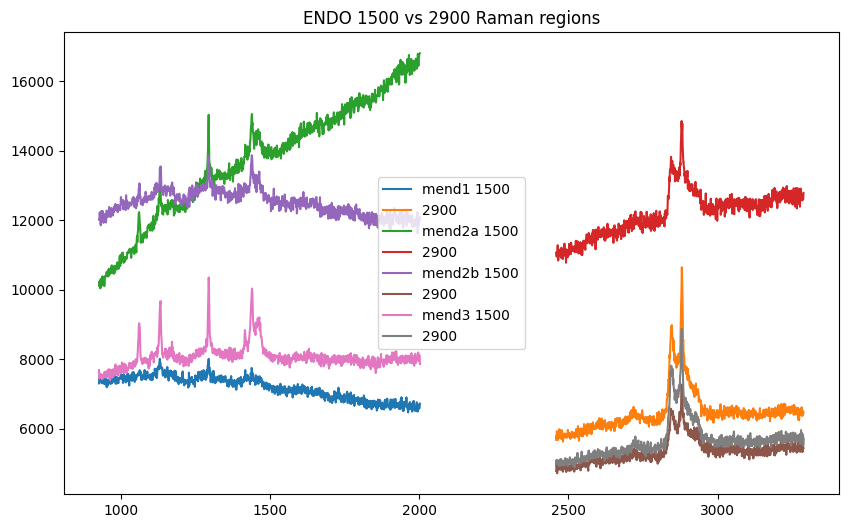

In [ ]:
plt.figure(figsize=(10,6))

for folder in folders:

    folder_path = os.path.join(base_path, folder)

    for file in os.listdir(folder_path):

        if "1500" in file and "Average" not in file:

            file_path = os.path.join(folder_path, file)

            df = pd.read_csv(
                file_path,
                sep=r"\s+",
                header=None,
                skiprows=1,
                names=["X","Y","Wave","Intensity"]
            )

            group = list(df.groupby(["X","Y"]))[0][1]

            plt.plot(group["Wave"], group["Intensity"], label=f"{folder} 1500")

            break

    for file in os.listdir(folder_path):

        if "2900" in file and "Average" not in file:

            file_path = os.path.join(folder_path, file)

            df = pd.read_csv(
                file_path,
                sep=r"\s+",
                header=None,
                skiprows=1,
                names=["X","Y","Wave","Intensity"]
            )

            group = list(df.groupby(["X","Y"]))[0][1]

            plt.plot(group["Wave"], group["Intensity"], label="2900")

            break

plt.legend()
plt.title("ENDO 1500 vs 2900 Raman regions")

plt.show()

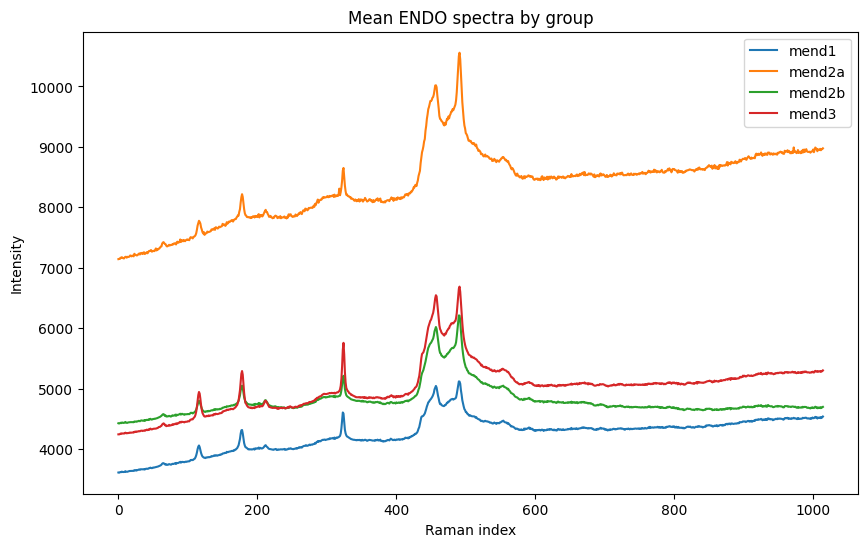

In [ ]:
import numpy as np

plt.figure(figsize=(10,6))

for folder in folders:

    folder_path = os.path.join(base_path, folder)

    spectra = []

    for file in os.listdir(folder_path):

        if "Average" in file:
            continue

        file_path = os.path.join(folder_path, file)

        df = pd.read_csv(
            file_path,
            sep=r"\s+",
            header=None,
            skiprows=1,
            names=["X","Y","Wave","Intensity"]
        )

        mean_spec = df.groupby("Wave")["Intensity"].mean().values

        spectra.append(mean_spec)

    spectra = np.array(spectra)

    plt.plot(np.mean(spectra, axis=0), label=folder)

plt.legend()

plt.title("Mean ENDO spectra by group")

plt.xlabel("Raman index")
plt.ylabel("Intensity")

plt.show()

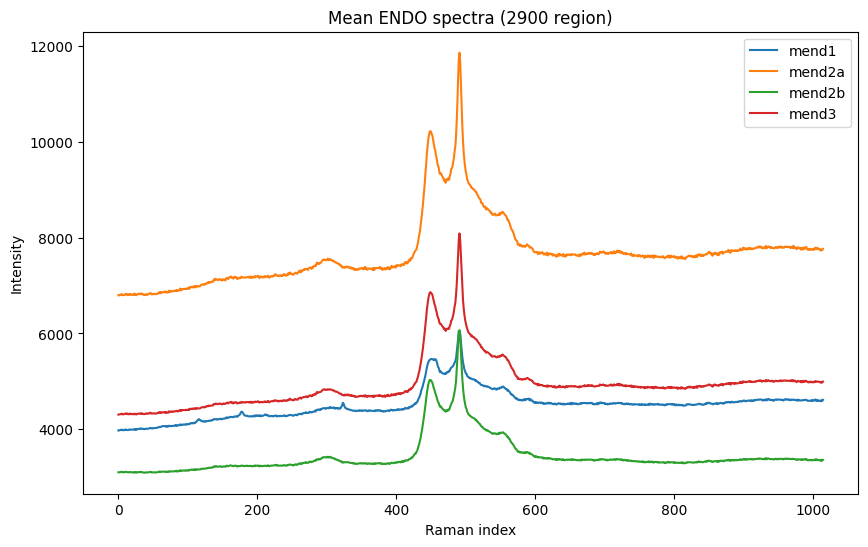

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

base_path = "/content/drive/MyDrive/Colab Notebooks/hack/endo"

folders = ["mend1","mend2a","mend2b","mend3"]

plt.figure(figsize=(10,6))

for folder in folders:

    folder_path = os.path.join(base_path, folder)

    spectra = []

    for file in os.listdir(folder_path):

        if "2900" not in file:
            continue

        if "Average" in file:
            continue

        file_path = os.path.join(folder_path, file)

        df = pd.read_csv(
            file_path,
            sep=r"\s+",
            header=None,
            skiprows=1,
            names=["X","Y","Wave","Intensity"]
        )

        mean_spec = df.groupby("Wave")["Intensity"].mean().values

        spectra.append(mean_spec)

    spectra = np.array(spectra)

    plt.plot(np.mean(spectra, axis=0), label=folder)

plt.legend()

plt.title("Mean ENDO spectra (2900 region)")
plt.xlabel("Raman index")
plt.ylabel("Intensity")

plt.show()

##preprocessing

In [11]:
import numpy as np

X_endo = np.array(data_endo)
y_endo = np.array(labels_endo)
groups_endo = np.array(groups_endo)

print("Shape:", X_endo.shape)

Shape: (38325, 1015)


In [ ]:
X_endo_norm = X_endo / X_endo.max(axis=1, keepdims=True)
X_endo_scaled = scaler.transform(X_endo_norm)

##PCA

In [ ]:
X_endo_pca = pca.transform(X_endo_scaled)

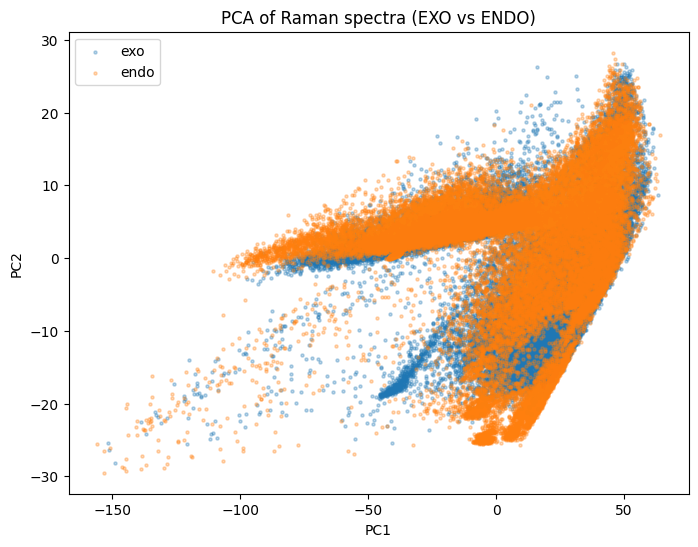

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# EXO
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    s=5,
    alpha=0.3,
    label="exo"
)

# ENDO
plt.scatter(
    X_endo_pca[:,0],
    X_endo_pca[:,1],
    s=5,
    alpha=0.3,
    label="endo"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Raman spectra (EXO vs ENDO)")
plt.legend()

plt.show()

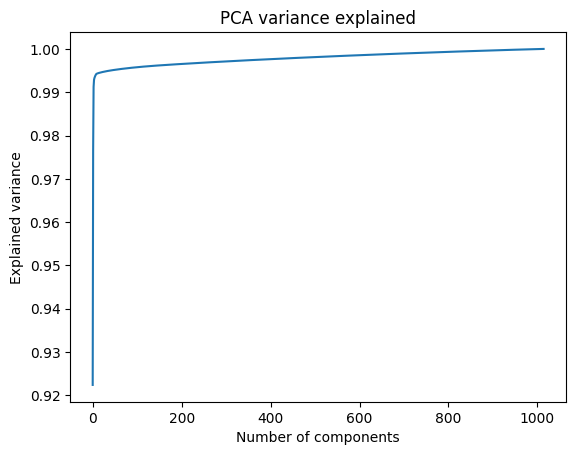

In [ ]:
pca_full = PCA()
pca_full.fit(X_scaled)

plt.plot(np.cumsum(pca_full.explained_variance_ratio_))

plt.xlabel("Number of components")
plt.ylabel("Explained variance")
plt.title("PCA variance explained")

plt.show()

##save

In [ ]:
np.save("/content/drive/MyDrive/Colab Notebooks/hack/X_endo_raw.npy", X_endo)
np.save("/content/drive/MyDrive/Colab Notebooks/hack/X_endo_norm.npy", X_endo_norm)
np.save("/content/drive/MyDrive/Colab Notebooks/hack/X_endo_scaled.npy", X_endo_scaled)

np.save("/content/drive/MyDrive/Colab Notebooks/hack/y_endo.npy", y_endo)


In [12]:
np.save("/content/drive/MyDrive/Colab Notebooks/hack/groups_endo.npy", groups_endo)

In [ ]:
X_test = np.load("/content/drive/MyDrive/Colab Notebooks/hack/X_endo_scaled.npy")

print(X_test.shape)

(38325, 1015)


#control

In [15]:
import pandas as pd
import os

base_path = "/content/drive/MyDrive/Colab Notebooks/hack/control"

folders = ["mk1", "mk2a", "mk2b", "mk3"]

data_control = []
labels_control = []
groups_control = []

for folder in folders:

    folder_path = os.path.join(base_path, folder)

    for file in os.listdir(folder_path):

        if "Average" in file:
            continue

        print("\nReading:", folder, file)

        file_path = os.path.join(folder_path, file)

        df = pd.read_csv(
            file_path,
            sep=r"\s+",
            header=None,
            skiprows=1,
            names=["X","Y","Wave","Intensity"]
        )

        spectra_count = df.groupby(["X","Y"]).ngroups
        print("Spectra in file:", spectra_count)

        for (x, y), group in df.groupby(["X","Y"]):

            spectrum = group["Intensity"].values

            data_control.append(spectrum)
            labels_control.append("control")
            groups_control.append(folder)

print("Total CONTROL spectra:", len(data_control))


Reading: mk1 cortex_control_1group_633nm_center1500_obj100_power100_1s_5acc_map35x15_step2_place4_1.txt
Spectra in file: 525

Reading: mk1 cortex_control_1group_633nm_center1500_obj100_power100_1s_5acc_map35x15_step2_place4_2.txt
Spectra in file: 525

Reading: mk1 cortex_control_1group_633nm_center1500_obj100_power100_1s_5acc_map35x15_step2_place5_2.txt
Spectra in file: 525

Reading: mk1 cortex_control_1group_633nm_center1500_obj100_power100_1s_5acc_map35x15_step2_place5_1.txt
Spectra in file: 525

Reading: mk1 cortex_control_1group_633nm_center1500_obj100_power100_1s_5acc_map35x15_step2_place6_1.txt
Spectra in file: 525

Reading: mk1 cortex_control_1group_633nm_center1500_obj100_power100_1s_5acc_map35x15_step2_place6_2.txt
Spectra in file: 525

Reading: mk1 cortex_control_1group_633nm_center2900_obj100_power100_1s_5acc_map35x15_step2_place4_1.txt
Spectra in file: 525

Reading: mk1 cortex_control_1group_633nm_center2900_obj100_power100_1s_5acc_map35x15_step2_place4_2.txt
Spectra in fi

In [ ]:
df.shape

(532875, 4)

In [ ]:
df.head()

,X,Y,Wave,Intensity
0,-11718.383324,-24601.15375,3288.216797,1908.346069
1,-11718.383324,-24601.15375,3287.474609,1867.814819
2,-11718.383324,-24601.15375,3286.730469,1935.008911
3,-11718.383324,-24601.15375,3285.987305,1904.263794
4,-11718.383324,-24601.15375,3285.244141,1927.541870


In [ ]:
df.groupby(["X","Y"]).size()

X              Y           
-11718.383324  -24601.15375    1015
               -24599.15375    1015
               -24597.15375    1015
               -24595.15375    1015
               -24593.15375    1015
                               ... 
-11650.383324  -24581.15375    1015
               -24579.15375    1015
               -24577.15375    1015
               -24575.15375    1015
               -24573.15375    1015
Length: 525, dtype: int64

In [ ]:
df.groupby(["X","Y"]).size().unique()

array([1015])

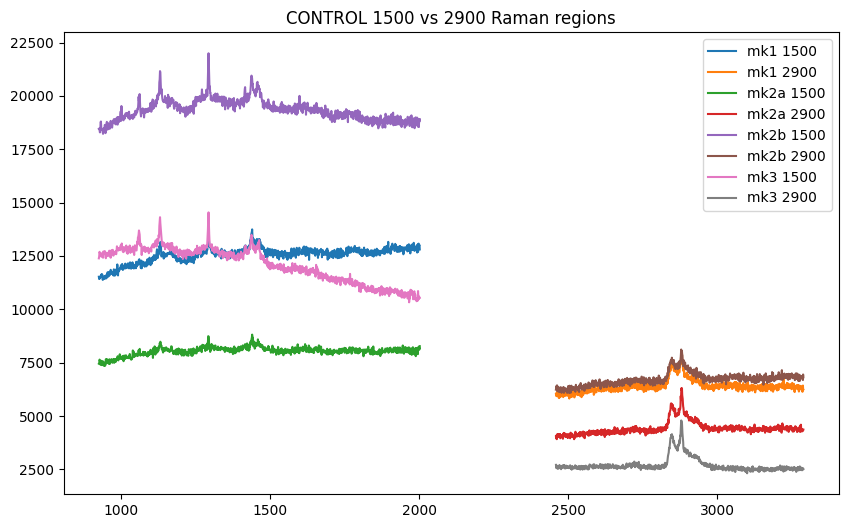

In [ ]:
plt.figure(figsize=(10,6))

base_path = "/content/drive/MyDrive/Colab Notebooks/hack/control"
folders = ["mk1","mk2a","mk2b","mk3"]

for folder in folders:

    folder_path = os.path.join(base_path, folder)

    for file in os.listdir(folder_path):

        if "1500" in file and "Average" not in file:

            file_path = os.path.join(folder_path, file)

            df = pd.read_csv(
                file_path,
                sep=r"\s+",
                header=None,
                skiprows=1,
                names=["X","Y","Wave","Intensity"]
            )

            group = list(df.groupby(["X","Y"]))[0][1]

            plt.plot(group["Wave"], group["Intensity"], label=f"{folder} 1500")

            break

    for file in os.listdir(folder_path):

        if "2900" in file and "Average" not in file:

            file_path = os.path.join(folder_path, file)

            df = pd.read_csv(
                file_path,
                sep=r"\s+",
                header=None,
                skiprows=1,
                names=["X","Y","Wave","Intensity"]
            )

            group = list(df.groupby(["X","Y"]))[0][1]

            plt.plot(group["Wave"], group["Intensity"], label=f"{folder} 2900")

            break

plt.legend()
plt.title("CONTROL 1500 vs 2900 Raman regions")

plt.show()

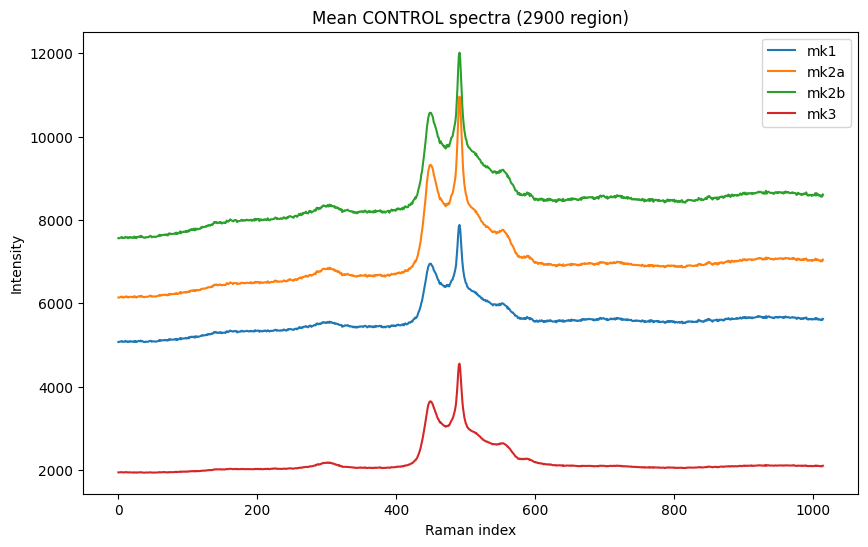

In [ ]:
plt.figure(figsize=(10,6))

for folder in folders:

    folder_path = os.path.join(base_path, folder)

    spectra = []

    for file in os.listdir(folder_path):

        if "2900" not in file:
            continue

        if "Average" in file:
            continue

        file_path = os.path.join(folder_path, file)

        df = pd.read_csv(
            file_path,
            sep=r"\s+",
            header=None,
            skiprows=1,
            names=["X","Y","Wave","Intensity"]
        )

        mean_spec = df.groupby("Wave")["Intensity"].mean().values

        spectra.append(mean_spec)

    spectra = np.array(spectra)

    plt.plot(np.mean(spectra, axis=0), label=folder)

plt.legend()

plt.title("Mean CONTROL spectra (2900 region)")
plt.xlabel("Raman index")
plt.ylabel("Intensity")

plt.show()

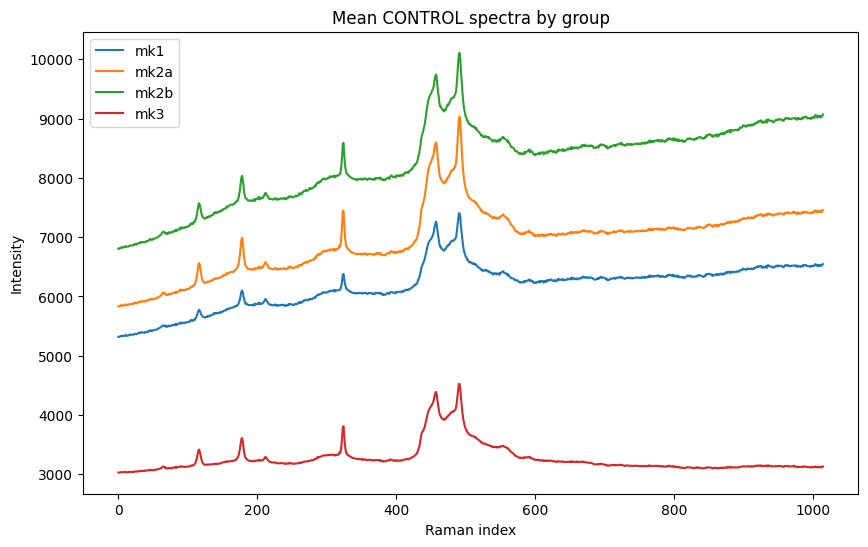

In [ ]:
import numpy as np

plt.figure(figsize=(10,6))

for folder in folders:

    folder_path = os.path.join(base_path, folder)

    spectra = []

    for file in os.listdir(folder_path):

        if "Average" in file:
            continue

        file_path = os.path.join(folder_path, file)

        df = pd.read_csv(
            file_path,
            sep=r"\s+",
            header=None,
            skiprows=1,
            names=["X","Y","Wave","Intensity"]
        )

        mean_spec = df.groupby("Wave")["Intensity"].mean().values

        spectra.append(mean_spec)

    spectra = np.array(spectra)

    plt.plot(np.mean(spectra, axis=0), label=folder)

plt.legend()

plt.title("Mean CONTROL spectra by group")

plt.xlabel("Raman index")
plt.ylabel("Intensity")

plt.show()

##PCA


In [ ]:
import numpy as np

X_control = np.array(data_control)
y_control = np.array(labels_control)
groups_control = np.array(groups_control)

print("Shape:", X_control.shape)
print("Labels:", len(y_control))

In [ ]:
X_control_norm = X_control / X_control.max(axis=1, keepdims=True)

X_control_scaled = scaler.transform(X_control_norm)

X_control_pca = pca.transform(X_control_scaled)

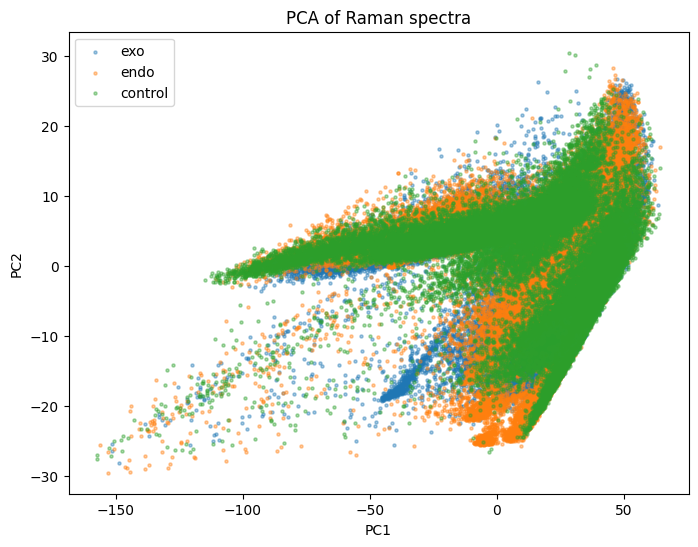

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(X_pca[:,0], X_pca[:,1], s=5, alpha=0.4, label="exo")
plt.scatter(X_endo_pca[:,0], X_endo_pca[:,1], s=5, alpha=0.4, label="endo")
plt.scatter(X_control_pca[:,0], X_control_pca[:,1], s=5, alpha=0.4, label="control")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Raman spectra")

plt.legend()
plt.show()

##save

In [ ]:
np.save("/content/drive/MyDrive/Colab Notebooks/hack/X_control_raw.npy", X_control)
np.save("/content/drive/MyDrive/Colab Notebooks/hack/X_control_norm.npy", X_control_norm)
np.save("/content/drive/MyDrive/Colab Notebooks/hack/X_control_scaled.npy", X_control_scaled)

np.save("/content/drive/MyDrive/Colab Notebooks/hack/y_control.npy", y_control)

In [16]:
np.save("/content/drive/MyDrive/Colab Notebooks/hack/groups_control.npy", groups_control)

In [ ]:
X_test = np.load("/content/drive/MyDrive/Colab Notebooks/hack/X_control_scaled.npy")

print(X_test.shape)

(42000, 1015)


In [21]:
print(np.unique( groups))

['mexo1' 'mexo2a' 'mexo2b' 'mexo3']
